# MBTI Personality Analysis — Advanced EDA (Volunteers)
This notebook adds cross-tab analyses (MBTI × Gender/Occupation) and age distributions to complement the core distribution plot.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Paths
DATA_PATH = Path('participants_mbti.csv')
OUTPUT_DIR = Path('.')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load dataset
df = pd.read_csv(DATA_PATH)
# Normalize MBTI codes to uppercase
df['MBTI'] = df['MBTI'].astype(str).str.strip().str.upper()
# Ensure Age is numeric if present
if 'Age' in df.columns:
    df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

df.head()

,Name,Age,Gender,City,Country,MBTI,Occupation
0,Najeebulllah Siddique,20,Male,Karachi,Pakistan,INFP,Student/Graphic Designer
1,Usmanullah Hussainy,19,Male,Karachi,Pakistan,INTP,Student/Web Developer
2,Ahmed Ali,18,Male,Karachi,Pakistan,ISFP,Student/Web Developer
3,Ali Raza,21,Male,Karachi,Pakistan,ISFJ,Student
4,Ahmed Hussain,20,Male,Karachi,Pakistan,ESFP,Student/Gamer


## MBTI × Gender — Counts and Heatmap
We explore how MBTI types distribute across Gender.

Gender,Female,Male
MBTI,,
ENFP,0,1
ENTJ,1,0
ESFJ,1,2
ESFP,0,2
ESTJ,0,1
INFP,1,6
INTP,0,4
ISFJ,0,1
ISFP,0,1


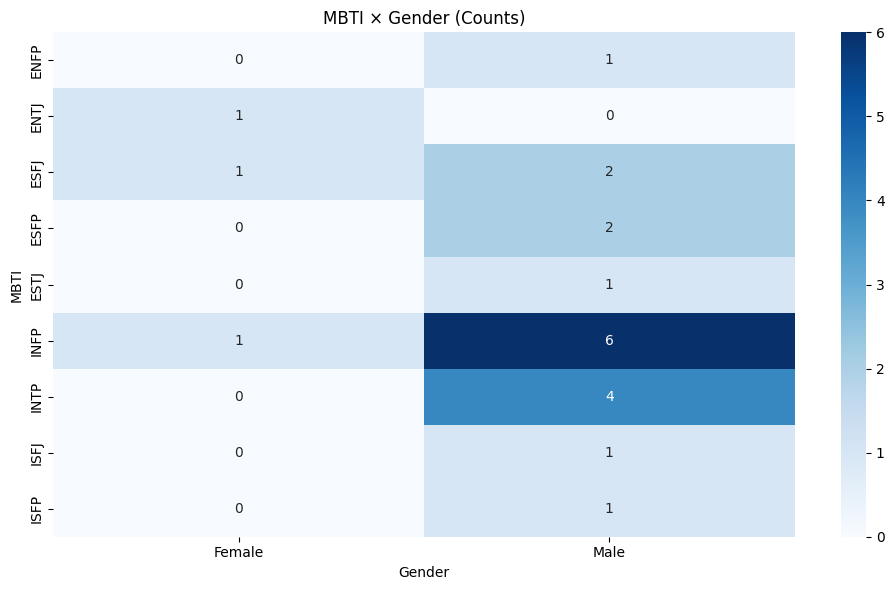

WindowsPath('advanced_mbti_gender_heatmap.png')

In [2]:
# Cross-tab counts
ct_gender = pd.crosstab(df['MBTI'], df['Gender'])
display(ct_gender)

# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(ct_gender, annot=True, fmt='d', cmap='Blues')
plt.title('MBTI × Gender (Counts)')
plt.tight_layout()
gender_heatmap_path = OUTPUT_DIR / 'advanced_mbti_gender_heatmap.png'
plt.savefig(gender_heatmap_path)
plt.show()
gender_heatmap_path

## MBTI × Occupation — Counts and Heatmap
We analyze MBTI distribution across Occupation. If there are many unique occupations, consider grouping.

Occupation,Bussiness Management,Construction Manager,Electrician,Entrepreneur,Fashion Designer,Lawyer,Makeup Artist,Nurse,Police Constable,Retired Nurse,Student,Student/Ai Research Engineer,Student/Entrepreneur,Student/Gamer,Student/Graphic Designer,Student/Qari,Student/Web Developer,Textile Designer
MBTI,,,,,,,,,,,,,,,,,,
ENFP,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
ENTJ,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
ESFJ,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0
ESFP,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
ESTJ,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
INFP,1,0,0,0,0,0,0,1,0,1,2,0,0,0,1,0,0,1
INTP,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0
ISFJ,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
ISFP,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


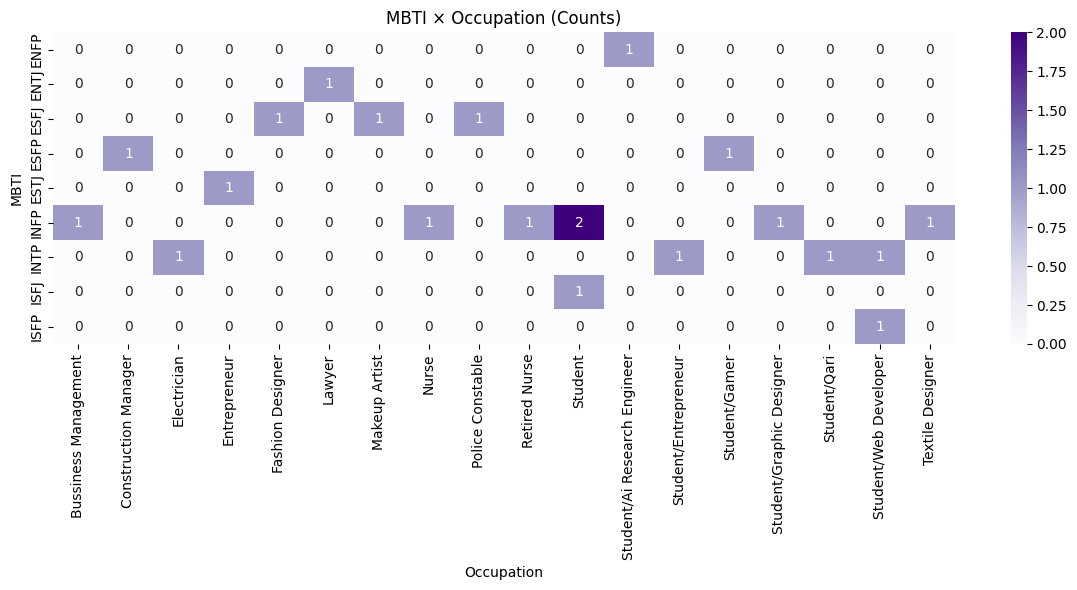

WindowsPath('advanced_mbti_occupation_heatmap.png')

In [3]:
# Cross-tab counts
ct_occ = pd.crosstab(df['MBTI'], df['Occupation'])
display(ct_occ)

# Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(ct_occ, annot=True, fmt='d', cmap='Purples')
plt.title('MBTI × Occupation (Counts)')
plt.tight_layout()
occupation_heatmap_path = OUTPUT_DIR / 'advanced_mbti_occupation_heatmap.png'
plt.savefig(occupation_heatmap_path)
plt.show()
occupation_heatmap_path

## Age Distribution by MBTI
We examine how age varies across MBTI types using boxplots.

C:\Users\Fozan\AppData\Local\Temp\ipykernel_17356\914904102.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='MBTI', y='Age', palette='Set2')


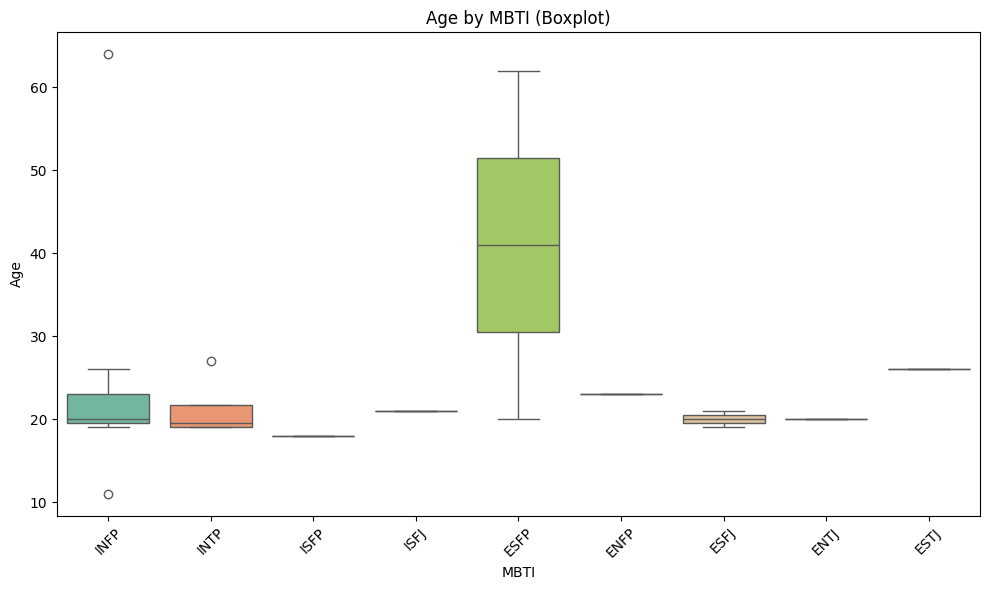

WindowsPath('advanced_age_by_mbti.png')

In [4]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='MBTI', y='Age', palette='Set2')
plt.title('Age by MBTI (Boxplot)')
plt.xticks(rotation=45)
plt.tight_layout()
age_boxplot_path = OUTPUT_DIR / 'advanced_age_by_mbti.png'
plt.savefig(age_boxplot_path)
plt.show()
age_boxplot_path

## Occupation Grouping and Percentage Cross-Tabs
We group raw occupation titles into broader categories and compute percent-based cross-tabs (column-wise and row-wise).

Occupation_Group,Design/Creative,Management,Other,Student/Trainee
MBTI,,,,
ENFP,0,0,0,1
ENTJ,0,0,1,0
ESFJ,1,0,2,0
ESFP,0,1,0,1
ESTJ,0,0,1,0
INFP,1,0,3,3
INTP,0,0,1,3
ISFJ,0,0,0,1
ISFP,0,0,0,1


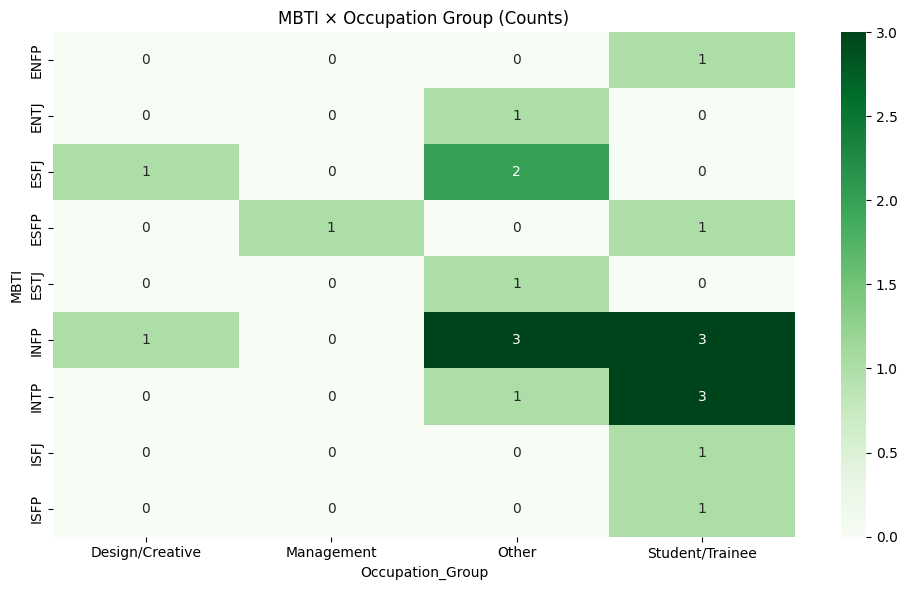

WindowsPath('advanced_mbti_occupation_group_heatmap.png')

In [5]:
# Group occupation categories
def group_occupation(raw):
    s = str(raw).strip().lower()
    if any(k in s for k in ['student', 'intern', 'trainee']):
        return 'Student/Trainee'
    if any(k in s for k in ['engineer', 'developer', 'programmer', 'software', 'data', 'ml', 'ai', 'it']):
        return 'Engineering/Tech'
    if any(k in s for k in ['designer', 'design', 'ui', 'ux', 'graphic']):
        return 'Design/Creative'
    if any(k in s for k in ['manager', 'lead', 'head', 'director']):
        return 'Management'
    if any(k in s for k in ['research', 'scientist', 'analyst']):
        return 'Research/Analysis'
    if any(k in s for k in ['marketing', 'sales', 'business', 'operations', 'finance', 'account']):
        return 'Business/Operations'
    if s in ('', 'nan', 'none'):
        return 'Unknown'
    return 'Other'

if 'Occupation' in df.columns:
    df['Occupation_Group'] = df['Occupation'].apply(group_occupation)
else:
    df['Occupation_Group'] = 'Unknown'

# Cross-tab counts on grouped occupation
ct_occ_group = pd.crosstab(df['MBTI'], df['Occupation_Group'])
display(ct_occ_group)

# Heatmap counts for grouped occupation
plt.figure(figsize=(10, 6))
sns.heatmap(ct_occ_group, annot=True, fmt='d', cmap='Greens')
plt.title('MBTI × Occupation Group (Counts)')
plt.tight_layout()
occ_group_heatmap_path = OUTPUT_DIR / 'advanced_mbti_occupation_group_heatmap.png'
plt.savefig(occ_group_heatmap_path)
plt.show()
occ_group_heatmap_path

Occupation_Group,Design/Creative,Management,Other,Student/Trainee
MBTI,,,,
ENFP,0.0,0.0,0.0,10.0
ENTJ,0.0,0.0,12.5,0.0
ESFJ,50.0,0.0,25.0,0.0
ESFP,0.0,100.0,0.0,10.0
ESTJ,0.0,0.0,12.5,0.0
INFP,50.0,0.0,37.5,30.0
INTP,0.0,0.0,12.5,30.0
ISFJ,0.0,0.0,0.0,10.0
ISFP,0.0,0.0,0.0,10.0


Occupation_Group,Design/Creative,Management,Other,Student/Trainee
MBTI,,,,
ENFP,0.0,0.0,0.0,100.0
ENTJ,0.0,0.0,100.0,0.0
ESFJ,33.3,0.0,66.7,0.0
ESFP,0.0,50.0,0.0,50.0
ESTJ,0.0,0.0,100.0,0.0
INFP,14.3,0.0,42.9,42.9
INTP,0.0,0.0,25.0,75.0
ISFJ,0.0,0.0,0.0,100.0
ISFP,0.0,0.0,0.0,100.0


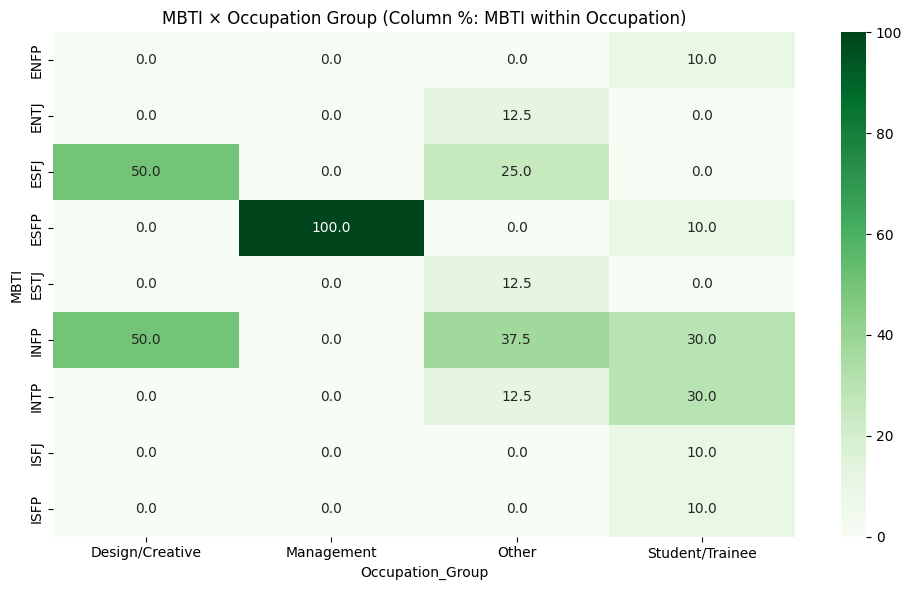

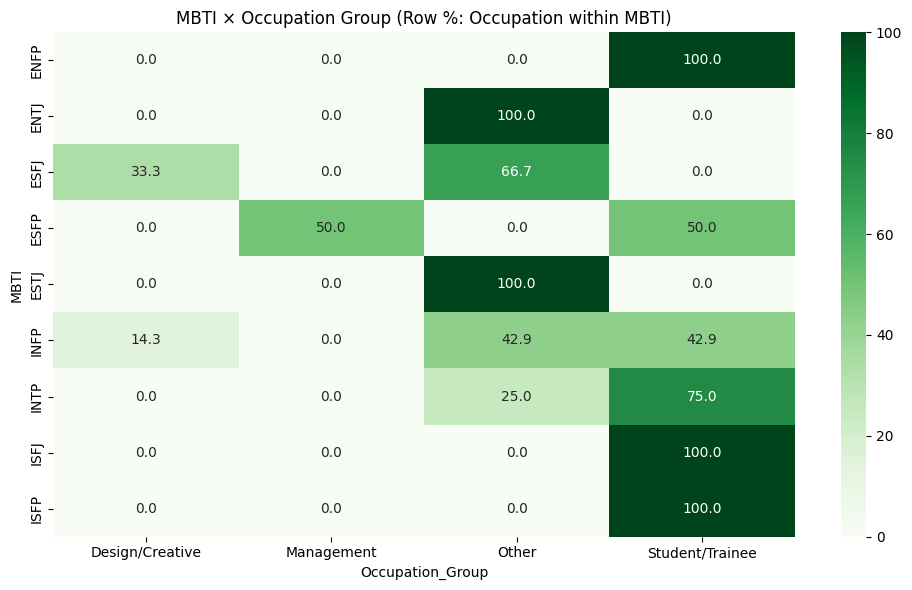

(WindowsPath('advanced_mbti_occupation_group_colpct_heatmap.png'),
 WindowsPath('advanced_mbti_occupation_group_rowpct_heatmap.png'))

In [6]:
# Percentage cross-tabs for Occupation Group
col_pct_occ = ct_occ_group.div(ct_occ_group.sum(axis=0), axis=1).fillna(0) * 100
row_pct_occ = ct_occ_group.div(ct_occ_group.sum(axis=1), axis=0).fillna(0) * 100

display(col_pct_occ.round(1))
display(row_pct_occ.round(1))

plt.figure(figsize=(10, 6))
sns.heatmap(col_pct_occ, annot=True, fmt='.1f', cmap='Greens')
plt.title('MBTI × Occupation Group (Column %: MBTI within Occupation)')
plt.tight_layout()
occ_group_colpct_path = OUTPUT_DIR / 'advanced_mbti_occupation_group_colpct_heatmap.png'
plt.savefig(occ_group_colpct_path)
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(row_pct_occ, annot=True, fmt='.1f', cmap='Greens')
plt.title('MBTI × Occupation Group (Row %: Occupation within MBTI)')
plt.tight_layout()
occ_group_rowpct_path = OUTPUT_DIR / 'advanced_mbti_occupation_group_rowpct_heatmap.png'
plt.savefig(occ_group_rowpct_path)
plt.show()

occ_group_colpct_path, occ_group_rowpct_path

## Percentage Cross-Tabs — Gender
Percent-based views for MBTI × Gender (column-wise and row-wise).

Gender,Female,Male
MBTI,,
ENFP,0.0,5.6
ENTJ,33.3,0.0
ESFJ,33.3,11.1
ESFP,0.0,11.1
ESTJ,0.0,5.6
INFP,33.3,33.3
INTP,0.0,22.2
ISFJ,0.0,5.6
ISFP,0.0,5.6


Gender,Female,Male
MBTI,,
ENFP,0.0,100.0
ENTJ,100.0,0.0
ESFJ,33.3,66.7
ESFP,0.0,100.0
ESTJ,0.0,100.0
INFP,14.3,85.7
INTP,0.0,100.0
ISFJ,0.0,100.0
ISFP,0.0,100.0


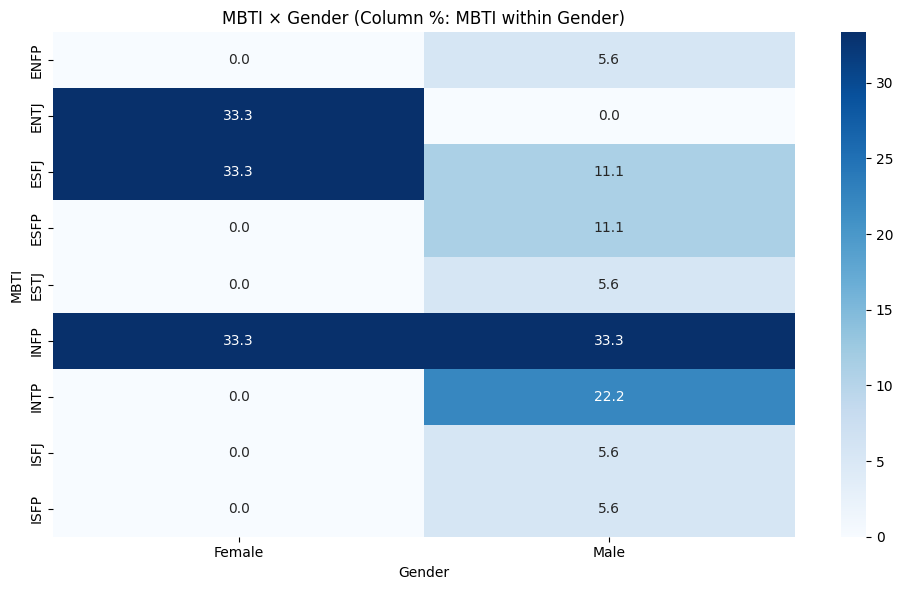

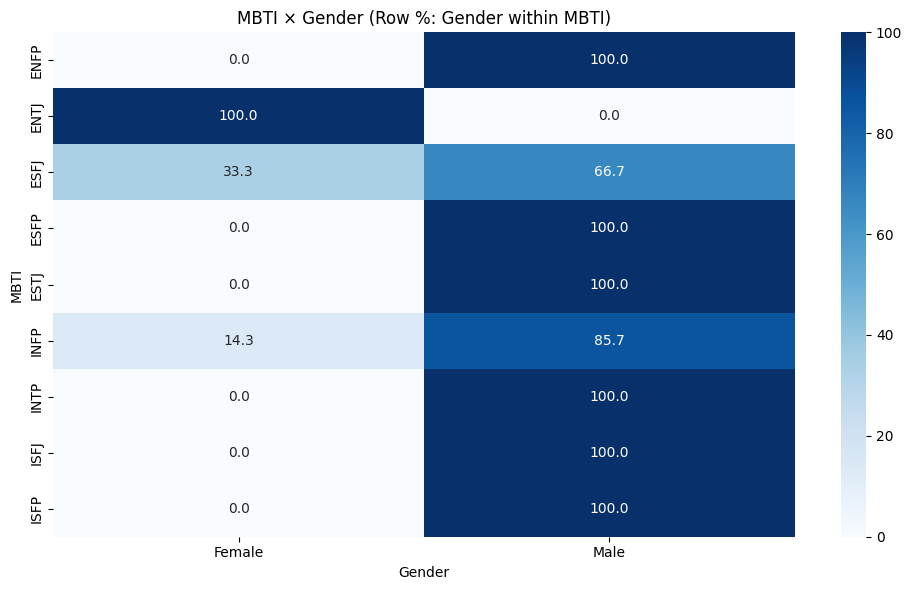

(WindowsPath('advanced_mbti_gender_colpct_heatmap.png'),
 WindowsPath('advanced_mbti_gender_rowpct_heatmap.png'))

In [7]:
# Percentage cross-tabs for Gender
col_pct_gender = ct_gender.div(ct_gender.sum(axis=0), axis=1).fillna(0) * 100
row_pct_gender = ct_gender.div(ct_gender.sum(axis=1), axis=0).fillna(0) * 100

display(col_pct_gender.round(1))
display(row_pct_gender.round(1))

plt.figure(figsize=(10, 6))
sns.heatmap(col_pct_gender, annot=True, fmt='.1f', cmap='Blues')
plt.title('MBTI × Gender (Column %: MBTI within Gender)')
plt.tight_layout()
gender_colpct_path = OUTPUT_DIR / 'advanced_mbti_gender_colpct_heatmap.png'
plt.savefig(gender_colpct_path)
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(row_pct_gender, annot=True, fmt='.1f', cmap='Blues')
plt.title('MBTI × Gender (Row %: Gender within MBTI)')
plt.tight_layout()
gender_rowpct_path = OUTPUT_DIR / 'advanced_mbti_gender_rowpct_heatmap.png'
plt.savefig(gender_rowpct_path)
plt.show()

gender_colpct_path, gender_rowpct_path

## Notes
- The dataset is small and illustrative; avoid overgeneralizing results.
- Occupation grouping uses simple keyword rules; refine as data grows.
- All output images are saved under `PersonalityAnalysis/` for sharing and versioning.